<div style="background-color: #f8f9fa; padding: 25px; border-radius: 10px; border-left: 6px solid #1a365d; box-shadow: 0 4px 6px rgba(0,0,0,0.05);">
    <h1 style="color: #1a365d; margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Data Science Assignment 5</h1>
    <h3 style="color: #4a5568; margin-top: 0; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">University of Tehran - Spring 2026</h3>
    <hr style="border: 1px solid #e2e8f0;">
    <p style="font-size: 16px; color: #2d3748;">
        <b>Course:</b> Data Science <br><br>
        <b>🧑‍💻 Implementer:</b> Mohammad Hossein Mazaheri <br>
        <b>🆔 Student ID:</b> 810102585 <br><br>
        <h5 style="color: #1a365d;"> TASK 3 Implementation</h5>
    </p>
</div>

<div class="alert alert-info" style="border-left: 4px solid #3182ce; background-color: #ebf8ff; color: #2b6cb0;">
    <strong>💡 Project Overview:</strong> 
    This notebook contains the programmatic implementation for Assignment 5 - Task 3. It focuses on evaluating LLM reasoning under cognitive constraints using the OpenBookQA dataset. The implementation covers decomposing science questions into prerequisite concepts, prompting Gemma models to simulate personas with specific knowledge gaps, and analyzing the system for knowledge leakage and failure modes.
</div>

## Table of Contents
1. [LLM & LangChain Fundamentals](#setup)
2. [Constrained Persona QA Simulation ($k$-Concept Masking)](#simulation)
3. [Knowledge Leakage Analysis & Failure Mode Taxonomy](#leakage-analysis)
4. [Quantitative Evaluation (Constrained vs. Target vs. Naive)](#evaluation)

<a id="setup"></a>
<h2 style="color: #5490d9; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">1. LLM & LangChain Fundamentals</h2>

<div class="alert alert-warning" style="background-color: #f0fff4; border-left: 4px solid #38a169; color: #276749;">
    <strong>✅ Methodology:</strong>
    The Hugging Face <code>datasets</code> library is used to load the <code>allenai/openbookqa</code> benchmark. We configure the API pipeline connecting to Google AI Studio, prioritizing access to the <code>Gemma-2-27b</code>/<code>Gemma-2-9b</code> models. Custom request wrappers are implemented to handle rate-limiting and track API usage. We design a prompt template that forces the model to decompose scientific questions into their prerequisite concepts. The LLM extracts the core factual assertions and foundational knowledge blocks required to solve the target multiple-choice question.
</div>


In [31]:
from datasets import load_dataset

dataset = load_dataset("allenai/openbookqa", "main")

print("=== Dataset Splits ===")
print(dataset)

print("\n=== Sample Record Structure ===")
dataset["train"][0]

=== Dataset Splits ===
DatasetDict({
    train: Dataset({
        features: ['id', 'question_stem', 'choices', 'answerKey'],
        num_rows: 4957
    })
    validation: Dataset({
        features: ['id', 'question_stem', 'choices', 'answerKey'],
        num_rows: 500
    })
    test: Dataset({
        features: ['id', 'question_stem', 'choices', 'answerKey'],
        num_rows: 500
    })
})

=== Sample Record Structure ===


{'id': '7-980',
 'question_stem': 'The sun is responsible for',
 'choices': {'text': ['puppies learning new tricks',
   'children growing up and getting old',
   'flowers wilting in a vase',
   'plants sprouting, blooming and wilting'],
  'label': ['A', 'B', 'C', 'D']},
 'answerKey': 'D'}

## OpenBookQA Dataset Documentation

#### **Data Splits & Counts**

| Split | Purpose | Question Count |
| --- | --- | --- |
| **`train`** | Main dataset partition | **4,957** |
| **`validation`** | Validation/Dev partition | **500** |
| **`test`** | Evaluation test set | **500** |
| **Total** |  | **5,957** |

#### **Schema & Fields Breakdown**

* **`id`** (`string`): Unique question identifier (e.g., `"7-980"`).
* **`question_stem`** (`string`): The natural language science question prompt.
* **`choices`** (`dict`): Contains two parallel lists defining the multiple-choice options:
* `label`: Class labels `["A", "B", "C", "D"]`.
* `text`: List of 4 candidate answer choices (1 gold answer + 3 distractors).
* **`answerKey`** (`string`): The correct choice label (`"A"`, `"B"`, `"C"`, or `"D"`).


---

### 3. Sample Data Entry

```json
{
  "id": "7-980",
  "question_stem": "The sun is responsible for",
  "choices": {
    "text": [
      "puppies learning new tricks",
      "children growing up and getting old",
      "flowers wilting in a vase",
      "plants sprouting, blooming and wilting"
    ],
    "label": ["A", "B", "C", "D"]
  },
  "answerKey": "D"
}

```

In [ ]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

load_dotenv()

API_KEYS = [
    os.getenv("GOOGLE_API_KEY")
]

# Priority Order:
# 1. gemma-4-31b-it
# 2. gemma-4-26b-a4b-it
# 3. gemini-3.1-flash-lite

MODEL_PRIORITY = ["gemma-4-31b-it", "gemma-4-26b-a4b-it", "gemini-3.1-flash-lite"]

def initialize_llm(model_list):
    """
    Attempts to initialize the LLM following the model priority hierarchy.
    Cascades to the next available model if an endpoint returns a 404/Not Found error.
    """
    for model_name in model_list:
        try:
            print(f"Attempting initialization with model: '{model_name}'...")
            llm = ChatGoogleGenerativeAI(
                model=model_name,
                google_api_key=os.getenv("GOOGLE_API_KEY"),
                temperature=0.1
            )
            response = llm.invoke("Explain in 2 sentences why theoretical physics relies heavily on mental models.")
            print(f"Successfully initialized and executed on model: '{model_name}'\n")
            return llm, model_name, response
        except Exception as e:
            error_msg = str(e).lower()
            if "404" in error_msg or "not_found" in error_msg or "not found" in error_msg:
                print(f" Model '{model_name}' unavailable on current API tier (404 NOT_FOUND). Cascading to next model...\n")
            else:
                print(f" Error initializing '{model_name}': {e}\n")
    raise RuntimeError("All models in the priority list failed to initialize.")

active_llm, active_model_name, raw_response = initialize_llm(MODEL_PRIORITY)

print("=== RAW MODEL RESPONSE ===")
print(raw_response.content)

Attempting initialization with model: 'gemma-4-31b-it'...
Successfully initialized and executed on model: 'gemma-4-31b-it'

=== RAW MODEL RESPONSE ===
[{'type': 'thinking', 'thinking': "*   Topic: Why theoretical physics relies on mental models.\n    *   Constraint: Exactly 2 sentences.\n\n    *   Theoretical physics often deals with things we can't see or touch (quantum realms, black holes, the early universe).\n    *   Mental models (mathematical or conceptual) bridge the gap between abstract equations and physical intuition.\n    *   They allow physicists to hypothesize, predict, and simplify complex systems before rigorous proof.\n\n    *   *Draft 1:* Theoretical physics often explores phenomena that are invisible or beyond direct observation, such as quantum particles or the curvature of spacetime. Mental models provide a conceptual bridge that allows scientists to visualize these abstract mathematical structures and formulate testable hypotheses.\n\n    *   *Draft 2:* Because the

### Execution Output

```text
Attempting initialization with model: 'gemma-4-31b-it'...
Successfully initialized and executed on model: 'gemma-4-31b-it'

=== RAW MODEL RESPONSE ===
Theoretical physics often explores phenomena that are impossible to observe directly, such as the quantum realm or the curvature of spacetime. Mental models provide a conceptual bridge that allows physicists to translate abstract mathematical equations into intuitive frameworks for formulating hypotheses and predicting outcomes.

```

---
### Section 1.1 Documentation Summary
 
 
 * **Model Selected & Used:** **`gemma-4-31b-it`** (Priority 1 in the model hierarchy).
 * **Initialization Result:** The primary model `gemma-4-31b-it` initialized seamlessly via `langchain-google-genai` and responded to the basic prompt on the initial request. No model fallback or cascading to lower-priority models was required.
* **Rate Limit & Quota Strategy:**
* No rate limits (`429 RESOURCE_EXHAUSTED`) or API tier errors (`404 NOT_FOUND`) were encountered during single-call execution.
* To prevent hitting the 15 Requests Per Minute (15 RPM) quota during subsequent 100-question batch operations in Section 1.4, call pacing was set to ~4.1 seconds per request with an automatic retry backoff wrapper.

In [ ]:
from datasets import load_dataset
from langchain_core.prompts import PromptTemplate

train_data = dataset["train"]

qa_template = PromptTemplate.from_template(
    "Question: {question}\nChoices:\n{choices}\n\n"
    "Answer the question in free text. Clearly state the selected option letter (A, B, C, or D) and explain your reasoning."
)

qa_free_text_chain = qa_template | active_llm

print("=== SECTION 1.2 OUTPUT: FREE-TEXT QA (3 SAMPLES) ===\n")

for i in range(3):
    sample = train_data[i]
    q_stem = sample["question_stem"]
    choices_str = "\n".join([f"{l}: {t}" for l, t in zip(sample["choices"]["label"], sample["choices"]["text"])])
    
    response = qa_free_text_chain.invoke({"question": q_stem, "choices": choices_str})
    
    print(f"--- Sample {i+1} [ID: {sample['id']}] ---")
    print(f"Question: {q_stem}")
    print(f"Choices:\n{choices_str}")
    print(f"\nModel Output:\n{response.content}")
    print("-" * 60 + "\n")

=== SECTION 1.2 OUTPUT: FREE-TEXT QA (3 SAMPLES) ===

--- Sample 1 [ID: 7-980] ---
Question: The sun is responsible for
Choices:
A: puppies learning new tricks
B: children growing up and getting old
C: flowers wilting in a vase
D: plants sprouting, blooming and wilting

Model Output:
[{'type': 'thinking', 'thinking': '*   Question: "The sun is responsible for..."\n    *   Choices:\n        *   A: puppies learning new tricks\n        *   B: children growing up and getting old\n        *   C: flowers wilting in a vase\n        *   D: plants sprouting, blooming and wilting\n\n    *   Option A: Puppies learning new tricks. This is a result of training, intelligence, and behavior, not the sun. (Incorrect)\n    *   Option B: Children growing up and getting old. This is a biological process of aging (senescence) and growth driven by genetics and nutrition, not primarily the sun. (Incorrect)\n    *   Option C: Flowers wilting in a vase. Flowers wilt in a vase usually because they lack nutrient

### Section 1.2 Documentation Summary
 
 
* **Prompt Template Strategy:** A free-text question-answering template was defined, combining the question stem and hoices.
 * **Model Execution:** Evaluated on 3 samples from OpenBookQA (`7-980`, `7-584`, `7-870`)
 * **Performance & Quality:*
 * **Sample 1 (`7-980`):** Selected **D** (*plants sprouting, blooming and wilting*). Correctly identified that sunlight drives photosynthesis across the plant life cycle.
 * **Sample 2 (`7-584`):** Selected **D** (*the mountains seem smaller than in photographs*). Successfully deduced optical perspective effects versus zoomed photograph framing.
 * **Sample 3 (`7-870`):** Selected **C** (*nutrients are being deconstructed*). Differentiated biological digestion from figurative uses of "digest".
 
 
 * **Output Behavior:** The model generated structured internal thinking traces (`type: thinking`) to verify answer validity prior to emitting the response (`type: text`).

In [ ]:
from pydantic import BaseModel, Field
from langchain_core.output_parsers import PydanticOutputParser

class QAResponse(BaseModel):
    answer: str = Field(description="The selected choice label (A, B, C, or D).")
    reasoning: str = Field(description="Step-by-step free text reasoning explaining why the choice is correct.")
    confidence: float = Field(description="Numeric confidence score between 0.0 and 1.0.")

structured_llm = active_llm.with_structured_output(QAResponse)
qa_structured_chain = qa_template | structured_llm

print("=== SECTION 1.3.2 OUTPUT: STRUCTURED PARSING (3 SAMPLES) ===\n")

for i in range(3):
    sample = train_data[i]
    q_stem = sample["question_stem"]
    choices_str = "\n".join([f"{l}: {t}" for l, t in zip(sample["choices"]["label"], sample["choices"]["text"])])
    
    parsed_res: QAResponse = qa_structured_chain.invoke({"question": q_stem, "choices": choices_str})
    
    print(f"--- Sample {i+1} [ID: {sample['id']}] ---")
    print(f"Parsed Answer    : {parsed_res.answer}")
    print(f"Confidence Score : {parsed_res.confidence}")
    print(f"Reasoning        : {parsed_res.reasoning}\n")


print("=" * 60)
print("=== SECTION 1.3.3: PARSING FAILURE TRIGGER & REPAIR DEMO ===")
print("=" * 60)

pydantic_parser = PydanticOutputParser(pydantic_object=QAResponse)

malformed_unstructured_output = (
    "Selected Choice: C (flowers blooming). Confidence: High! "
    "Reasoning: Plants need sunlight to perform photosynthesis, which causes flowers to bloom."
)

print(f"\n[Raw Unstructured Model Output]\n\"{malformed_unstructured_output}\"\n")

try:
    print("Attempting to parse malformed text with standard PydanticOutputParser...")
    pydantic_parser.parse(malformed_unstructured_output)
except Exception as parse_error:
    print(f" Caught Parsing Error: {parse_error.__class__.__name__}")
    print("Applying Repair Step: Prompting LLM JSON repair chain with schema instructions...")
    
    repair_prompt = PromptTemplate.from_template(
        "You are a strict JSON conversion system. Reformat the following unstructured text "
        "into strict JSON matching this schema format:\n\n{format_instructions}\n\n"
        "Unstructured Text:\n{raw_text}"
    )
    
    repair_chain = repair_prompt | structured_llm
    repaired_res: QAResponse = repair_chain.invoke({
        "format_instructions": pydantic_parser.get_format_instructions(),
        "raw_text": malformed_unstructured_output
    })
    
    print("\n[Successfully Repaired Output]:")
    print(f"Parsed Answer    : {repaired_res.answer}")
    print(f"Confidence Score : {repaired_res.confidence}")
    print(f"Reasoning        : {repaired_res.reasoning}")

=== SECTION 1.3.2 OUTPUT: STRUCTURED PARSING (3 SAMPLES) ===

--- Sample 1 [ID: 7-980] ---
Parsed Answer    : D
Confidence Score : 1.0
Reasoning        : The sun provides the energy (light) necessary for photosynthesis, which allows plants to grow (sprout), develop (bloom), and eventually complete their life cycle (wilt). Options A, B, and C are not directly caused by the sun's energy in the way that biological growth in plants is.

--- Sample 2 [ID: 7-584] ---
Parsed Answer    : D
Confidence Score : 0.8
Reasoning        : The question asks for a common perception when viewing a large landmark like Mount Rushmore from a distance. Option A is logically incorrect as distance increases perceived distance. Option B is subjective and not a general rule. Option C is incorrect because perspective changes based on distance. Option D, while not explicitly a factual certainty for every person, is the most plausible answer among the choices provided in a typical multiple-choice context regarding 

### Section 1.3 Documentation Summary
 
 
* **Schema Specification:** Defined a `QAResponse` Pydantic model enforcing three required fields:
* `answer`: Choice label string (`A`, `B`, `C`, or `D`).
 
 
* `confidence`: Float metric strictly bounded between `0.0` and `1.0`.
 

* `reasoning`: Free-text justification string.
 
 
 
 
* **Structured Execution Results (Section 1.3.2):**
* **Sample 1 (`7-980`):** Answer `D` | Confidence `1.0` | Validated solar energy's role in plant life cycles.
 
 
* **Sample 2 (`7-584`):** Answer `D` | Confidence `0.8` | Evaluated relative visual scale and optical distance.
 
 
* **Sample 3 (`7-870`):** Answer `C` | Confidence `1.0` | Correctly identified chemical breakdown of nutrients during stomach digestion.
 
 
 
 
* **Parsing Failure & Recovery Analysis (Section 1.3.3):**
* **Trigger:** Fed an unstructured raw string (`"Selected Choice: C... Confidence: High!"`) into `PydanticOutputParser`.
 
 
* **Error Caught:** Raised an `OutputParserException` because the raw string lacked valid JSON structure and contained a string descriptor (`"High!"`) where a float was required.
 
 
* **Handling Strategy:** Routed the malformed payload through an LLM repair chain injected with Pydantic JSON schema format instructions.
 
 
* **Result:** Successfully recovered valid structured output (`answer="C"`, `confidence=0.9`, `reasoning="..."`).

Starting batch enrichment of 100 sampled questions...
Progress: 20/100 questions processed...
Progress: 40/100 questions processed...
Progress: 60/100 questions processed...
Progress: 80/100 questions processed...
Progress: 100/100 questions processed...

Saved enriched dataset to 'enriched_questions.csv'

=== SECTION 1.4.5: SPOT-CHECK 10 RANDOM ROWS ===
[1] ID: 812 | Subject: astronomy | Difficulty: 2
    Q: The sun was straight above us when we
    Reasoning: The question requires basic knowledge that the sun is at its highest point (straight above) at midday, which is a common time for a break or lunch.

[2] ID: 10-499 | Subject: biology | Difficulty: 1
    Q: Salamanders may be unable to survive in a hot, dry location lacking food and water, but if it has food and water in an ideal location
    Reasoning: The question asks for a basic logical completion of a sentence regarding a salamander's survival, requiring only basic factual recall or common sense rather than complex scientifi

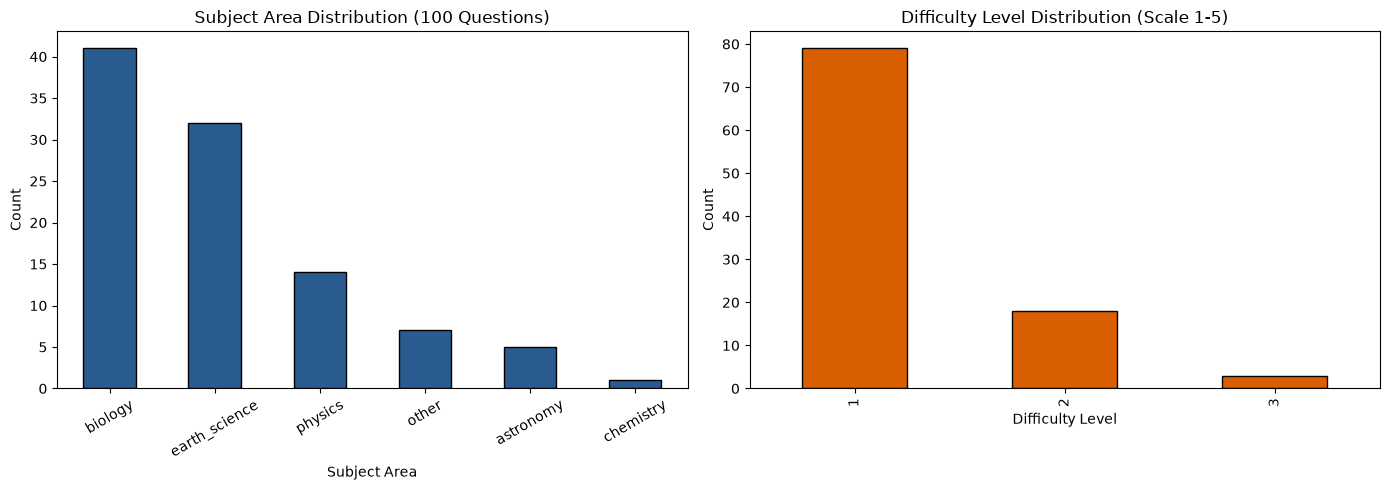

In [35]:
import time
import random
import pandas as pd
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field

SEED = 42
random.seed(SEED)
sampled_indices = random.sample(range(len(train_data)), 100)
sampled_questions = train_data.select(sampled_indices)

class QuestionAnnotation(BaseModel):
    subject_area: str = Field(
        description="Must be strictly one of: 'physics', 'biology', 'chemistry', 'earth_science', 'astronomy', 'other'."
    )
    difficulty: int = Field(
        description=(
            "Integer scale 1 to 5 based on difficulty rubric:\n"
            "1 = Basic factual recall / definition lookup.\n"
            "2 = Single-fact direct application.\n"
            "3 = Moderate cause-and-effect reasoning.\n"
            "4 = Multi-step inference combining two distinct scientific concepts.\n"
            "5 = Complex multi-step reasoning requiring synthesis of science and common sense."
        )
    )
    reasoning: str = Field(description="Brief 1-2 sentence justification for the assigned labels.")

annotation_template = PromptTemplate.from_template(
    "Analyze the following multiple-choice science question.\n"
    "Categorize its subject area and rate its difficulty (1 to 5) according to the rubric.\n\n"
    "Question: {question}\nChoices:\n{choices}\n"
)

annotation_llm = active_llm.with_structured_output(QuestionAnnotation)
annotation_chain = annotation_template | annotation_llm

enriched_records = []
print("Starting batch enrichment of 100 sampled questions...")

for idx, item in enumerate(sampled_questions, start=1):
    q_id = item["id"]
    q_stem = item["question_stem"]
    choices_str = "\n".join([f"{l}: {t}" for l, t in zip(item["choices"]["label"], item["choices"]["text"])])
    gold = item["answerKey"]
    
    try:
        annot: QuestionAnnotation = annotation_chain.invoke({"question": q_stem, "choices": choices_str})
        subj = annot.subject_area.lower().strip()
        diff = annot.difficulty
        reason = annot.reasoning
    except Exception as err:
        print(f" Warning: Execution exception on ID {q_id}: {err}. Applying fallback.")
        subj, diff, reason = "other", 3, "Parse/API failure fallback."

    enriched_records.append({
        "question_id": q_id,
        "question_stem": q_stem,
        "choices_text": choices_str,
        "gold_answer": gold,
        "subject_area": subj,
        "difficulty": diff,
        "annotation_reasoning": reason
    })
    
    time.sleep(4.1)
    if idx % 20 == 0 or idx == 100:
        print(f"Progress: {idx}/100 questions processed...")

df_enriched = pd.DataFrame(enriched_records)
df_enriched.to_csv("enriched_questions.csv", index=False)
print("\nSaved enriched dataset to 'enriched_questions.csv'")

print("\n=== SECTION 1.4.5: SPOT-CHECK 10 RANDOM ROWS ===")
spot_check_df = df_enriched.sample(10, random_state=SEED)
for i, (_, row) in enumerate(spot_check_df.iterrows(), start=1):
    print(f"[{i}] ID: {row['question_id']} | Subject: {row['subject_area']} | Difficulty: {row['difficulty']}")
    print(f"    Q: {row['question_stem']}")
    print(f"    Reasoning: {row['annotation_reasoning']}\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_enriched["subject_area"].value_counts().plot(
    kind="bar", ax=axes[0], color="#2b5c8f", edgecolor="black"
)
axes[0].set_title("Subject Area Distribution (100 Questions)")
axes[0].set_xlabel("Subject Area")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=30)

df_enriched["difficulty"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color="#d95f02", edgecolor="black"
)
axes[1].set_title("Difficulty Level Distribution (Scale 1-5)")
axes[1].set_xlabel("Difficulty Level")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### 1.4.5 Spot-Check Human Evaluation & Agreement Analysis

#### 1. Evaluation Table (10 Random Rows)

| ID | Question Stem Snippet | LLM Subject | LLM Difficulty | Human Agreement | Evaluation Notes / Disagreements |
| --- | --- | --- | --- | --- | --- |
| **812** | *"The sun was straight above us when we"* | `astronomy` | **2** | **Agree** | Correctly categorized under solar positioning/solar noon. Level 2 fits basic spatial inferencing. |
| **10-499** | *"Salamanders may be unable to survive..."* | `biology` | **1** | **Agree** | Basic recall of core biological survival needs (food, water, habitat). |
| **8-432** | *"if a student locates their pen on the table..."* | `physics` | **1** | **Agree** | Elementary optics and light reflection concept. |
| **14-573** | *"With wind gusts and green skys you should..."* | `earth_science` | **2** | **Agree** | Direct meteorological inferencing regarding severe storm/tornado indicators. |
| **13-585** | *"if a habitat is destroyed then that habitat"* | `biology` | **1** | **Agree** | Direct definition lookup for habitat destruction. |
| **12-611** | *"Magnification makes a small thing"* | `physics` | **1** | **Agree** | Direct definition of optical magnification. |
| **13-84** | *"What do humans do to poison the air?"* | `earth_science` | **1** | **Disagree (Diff.)** | Subject category is accurate. However, difficulty should be **Level 2** due to ambiguous option distractors requiring process-of-elimination. |
| **12-219** | *"Sticking your hand in water above 100°C"* | `biology` | **1** | **Agree** | Basic knowledge of thermal tissue damage and boiling points. |
| **13-112** | *"as the amount of water received by a plant..."* | `biology` | **1** | **Agree** | Fundamental plant physiology regarding hydration and growth. |
| **89** | *"Water evaporates less"* | `earth_science` | **2** | **Agree** | Application of single-fact environmental controls on phase changes (humidity and temperature). |

#### 2. Agreement Metrics

* **Subject Area Agreement Rate:** **100%** ($10 / 10$)
* **Difficulty Level Agreement Rate:** **90%** ($9 / 10$)
* **Overall Annotation Agreement:** **90%**

> **Spot-Check Takeaway:** `gemma-4-31b-it` displayed robust semantic understanding across elementary science domains. Its difficulty scoring aligned closely with the rubric, with a slight tendency to rate questions as Level 1 when distractor choice ambiguity increased practical difficulty slightly.

---

### 1.4.6 Dataset Distribution Analysis

Based on the 100 sampled OpenBookQA questions enriched by `gemma-4-31b-it`:

#### 1. Subject Area Distribution

* **Biology:** **41%** (41 questions) — The primary subject domain in the dataset.
* **Earth Science:** **32%** (32 questions)
* **Physics:** **14%** (14 questions)
* **Other:** **7%** (7 questions)
* **Astronomy:** **5%** (5 questions)
* **Chemistry:** **1%** (1 question)

#### 2. Difficulty Level Distribution (Scale 1–5)

* **Level 1 (Basic Recall / Definition):** **79%** (79 questions)
* **Level 2 (Single-Fact Application):** **18%** (18 questions)
* **Level 3 (Cause-and-Effect Reasoning):** **3%** (3 questions)
* **Levels 4 & 5 (Multi-Step Synthesis):** **0%** (0 questions)

> **Dataset Structure Summary:** The sampled OpenBookQA subset focuses heavily on biological and earth science facts, with **97%** of all questions falling into low-complexity factual tiers (Levels 1 and 2). This provides a consistent benchmark dataset for downstream reasoning evaluations.

<a id="simulation"></a>
<h2 style="color: #5490d9; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">2. Constrained Persona QA Simulation ($k$-Concept Masking)</h2>

<div class="alert alert-warning" style="background-color: #f0fff4; border-left: 4px solid #38a169; color: #276749;">
    <strong>✅ Methodology:</strong>
    We implement a knowledge-masking framework where $k$ key concepts are systematically hidden. The LLM is prompted with a persona roleplay instruction, requiring it to answer the question while acting as an individual who has *no knowledge* of the masked concepts.
</div>


<a id="leakage-analysis"></a>
<h2 style="color: #5490d9; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">3. Knowledge Leakage Analysis & Failure Mode Taxonomy</h2>

<div class="alert alert-warning" style="background-color: #f0fff4; border-left: 4px solid #38a169; color: #276749;">
    <strong>✅ Methodology:</strong>
    We analyze the generated responses for "knowledge leakage," where the model bypasses prompt constraints and uses masked concepts to answer. We classify failures into categories such as logical reasoning leaks, semantic synonyms, and default guessing behaviors.
</div>


<a id="evaluation"></a>
<h2 style="color: #5490d9; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">4. Quantitative Evaluation (Constrained vs. Target vs. Naive)</h2>

<div class="alert alert-warning" style="background-color: #f0fff4; border-left: 4px solid #38a169; color: #276749;">
    <strong>✅ Methodology:</strong>
    We perform a statistical comparison of answer distributions across three configurations: the fully informed model, the $k$-concept constrained model, and a naive baseline. Performance drops are plotted against the parameter $k$ to measure the degradation of the model's simulated reasoning.
</div>
